In [57]:
import os
import re
import math
import gc
import random
import numpy as np
import pandas as pd
import torch

from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy.stats import pointbiserialr, mannwhitneyu
from sklearn.metrics import roc_auc_score

Було вибрано мовну модель Qwen/Qwen2.5-1.5B-Instruct, що дозволило нам працювати в умовах обмежених ресурсів. Також він дозволяє продивлятись внутрішні стани, тому ідеально підходить для нашого дослідження. 

In [59]:
# =========================
# CONFIG
# =========================

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

N_EXAMPLES = 300
MAX_NEW_TOKENS = 16
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [61]:
def generate_problem(level=1):
    if level == 1:
        a = random.randint(10, 99)
        b = random.randint(10, 99)

        q = f"What is {a} + {b}?"
        ans = a + b

    elif level == 2:
        a = random.randint(10, 99)
        b = random.randint(10, 99)
        c = random.randint(1, 30)

        q = f"What is {a} + {b} - {c}?"
        ans = a + b - c

    elif level == 3:
        a = random.randint(2, 20)
        b = random.randint(2, 20)
        c = random.randint(1, 30)

        q = f"What is ({a} * {b}) + {c}?"
        ans = (a * b) + c

    elif level == 4:
        a = random.randint(10, 100)
        b = random.randint(10, 100)

        q = (
            f"John has {a} apples and buys {b} more apples. "
            f"How many apples does he have?"
        )
        ans = a + b

    elif level == 5:
        a = random.randint(20, 100)
        b = random.randint(1, 30)

        q = (
            f"Maria had {a} candies and gave away {b}. "
            f"How many candies does she have now?"
        )
        ans = a - b

    else:
        a = random.randint(2, 12)
        b = random.randint(2, 12)
        c = random.randint(1, 20)

        q = (
            f"A box has {a} rows with {b} items in each row. "
            f"Then {c} more items are added. "
            f"How many items are there in total?"
        )
        ans = a * b + c

    return q, ans

In [63]:
dataset = []

for i in range(N_EXAMPLES):
    level = random.choice([1, 2, 3, 4, 5, 6])
    q, ans = generate_problem(level)

    dataset.append({
        "sample_id": i,
        "question": q,
        "answer": ans,
        "level": level
    })

task_df = pd.DataFrame(dataset)
task_df.head(10)

,sample_id,question,answer,level
0,0,A box has 3 rows with 2 items in each row. The...,15,6
1,1,What is 38 + 27 - 24?,41,2
2,2,What is 96 + 79?,175,1
3,3,What is 85 + 64?,149,1
4,4,What is 13 + 21?,34,1
5,5,What is 39 + 74 - 20?,93,2
6,6,What is 81 + 35?,116,1
7,7,A box has 12 rows with 10 items in each row. T...,134,6
8,8,What is 67 + 85 - 9?,143,2
9,9,What is 30 + 99?,129,1


In [65]:
def format_prompt(question: str):
    return f"""
Answer the math question.

Return ONLY the final numeric answer.
Do not explain.
Do not show steps.

Question:
{question}

Answer:
""".strip()

In [67]:
def extract_final_number(text: str):
    nums = re.findall(r"[-+]?\d+(?:\.\d+)?", text.replace(",", ""))

    if not nums:
        return None

    x = float(nums[0])
    return int(round(x)) if abs(x - round(x)) < 1e-6 else x
    
def cosine_distance(a, b, eps=1e-8):
    a = a.float()
    b = b.float()

    return 1.0 - torch.dot(a, b) / (torch.norm(a) * torch.norm(b) + eps)

In [69]:
# =========================
# LOAD MODEL
# =========================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True
)

if DEVICE == "cpu":
    model.to(DEVICE)

model.eval()
model.config.use_cache = False

print("Model loaded.")

Model loaded.


In [71]:
@torch.no_grad()
def run_one_fast(sample_id, question, gold_answer, level):
    prompt = format_prompt(question)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    gen = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    prompt_len = inputs["input_ids"].shape[1]
    generated_ids_only = gen[0][prompt_len:]

    outputs = model(
        input_ids=gen,
        attention_mask=torch.ones_like(gen),
        output_hidden_states=True,
        return_dict=True,
        use_cache=False,
    )

    hidden_states = outputs.hidden_states[1:]

    local_token_rows = []
    prev_layer_vectors = None

    for step in range(len(generated_ids_only)):
        token_id = generated_ids_only[step].item()
        token_text = tokenizer.decode([token_id], skip_special_tokens=False)

        if len(token_text.strip()) == 0:
            continue

        pos = prompt_len + step

        layer_vectors = [
            h[0, pos, :].detach().float().cpu()
            for h in hidden_states
        ]

        layer_norms = torch.tensor([
            torch.norm(v).item()
            for v in layer_vectors
        ])

        if prev_layer_vectors is None:
            temporal_delta_mean = np.nan
            temporal_delta_max = np.nan
            temporal_cos_mean = np.nan
            final_layer_delta = np.nan
            pseudo_lyapunov = np.nan
        else:
            deltas = []
            coss = []

            for v_now, v_prev in zip(layer_vectors, prev_layer_vectors):
                deltas.append(torch.norm(v_now - v_prev).item())
                coss.append(cosine_distance(v_now, v_prev).item())

            temporal_delta_mean = float(np.mean(deltas))
            temporal_delta_max = float(np.max(deltas))
            temporal_cos_mean = float(np.mean(coss))

            final_layer_delta = float(
                torch.norm(layer_vectors[-1] - prev_layer_vectors[-1]).item()
            )

            pseudo_lyapunov = float(math.log(temporal_delta_mean + 1e-8))

        layer_deltas = [
            torch.norm(layer_vectors[i] - layer_vectors[i - 1]).item()
            for i in range(1, len(layer_vectors))
        ]

        layer_div_mean = float(np.mean(layer_deltas))
        layer_div_max = float(np.max(layer_deltas))
        layer_roughness = float(np.std(layer_deltas))
        norm_variance = float(torch.var(layer_norms).item())

        logits = outputs.logits[0, pos, :].float()
        probs = torch.softmax(logits, dim=-1)
        logit_entropy = float(
            -(probs * torch.log(probs + 1e-8)).sum().item()
        )

        local_token_rows.append({
            "sample_id": sample_id,
            "level": level,
            "step": step,
            "token_id": token_id,
            "token_text": token_text,

            "temporal_delta_mean": temporal_delta_mean,
            "temporal_delta_max": temporal_delta_max,
            "temporal_cos_mean": temporal_cos_mean,
            "final_layer_delta": final_layer_delta,

            "layer_div_mean": layer_div_mean,
            "layer_div_max": layer_div_max,
            "layer_roughness": layer_roughness,
            "norm_variance": norm_variance,

            "pseudo_lyapunov": pseudo_lyapunov,
            "logit_entropy": logit_entropy,
        })

        prev_layer_vectors = layer_vectors

    generated_text = tokenizer.decode(
        generated_ids_only,
        skip_special_tokens=True
    )

    pred_answer = extract_final_number(generated_text)
    correct = int(pred_answer == gold_answer)

    return generated_text, pred_answer, gold_answer, correct, local_token_rows

In [73]:
# =========================
# MAIN LOOP
# =========================
token_rows = []
sample_rows = []

for row in tqdm(dataset, desc="Running synthetic tasks", leave=True):
    sample_id = row["sample_id"]
    question = row["question"]
    gold_answer = row["answer"]
    level = row["level"]

    try:
        gen_text, pred, gold, correct, rows = run_one_fast(
            sample_id=sample_id,
            question=question,
            gold_answer=gold_answer,
            level=level
        )

        token_rows.extend(rows)
        df_tmp = pd.DataFrame(rows)

        if len(df_tmp) == 0:
            continue

        metric_cols = [
            "temporal_delta_mean",
            "temporal_delta_max",
            "temporal_cos_mean",
            "final_layer_delta",
            "layer_div_mean",
            "layer_div_max",
            "layer_roughness",
            "norm_variance",
            "pseudo_lyapunov",
            "logit_entropy",
        ]

        instability_scores = []

        for col in metric_cols:
            if col not in df_tmp.columns:
                continue

            x = df_tmp[col].replace([np.inf, -np.inf], np.nan).dropna()

            if len(x) >= 2 and x.std() > 1e-8:
                z = (x - x.mean()) / x.std()
                instability_scores.append(float(z.max()))

        instability_peak = (
            float(np.max(instability_scores))
            if len(instability_scores) > 0
            else np.nan
        )

        tail = df_tmp.tail(3)

        sample_rows.append({
            "sample_id": sample_id,
            "level": level,
            "question": question,
            "gold": gold,
            "pred": pred,
            "correct": correct,
            "generated_text": gen_text,
            "n_generated_tokens": len(rows),

            "instability_peak": instability_peak,

            "mean_temporal_delta": float(df_tmp["temporal_delta_mean"].mean(skipna=True)),
            "max_temporal_delta": float(df_tmp["temporal_delta_mean"].max(skipna=True)),
            "tail_temporal_delta": float(tail["temporal_delta_mean"].mean(skipna=True)),

            "mean_final_layer_delta": float(df_tmp["final_layer_delta"].mean(skipna=True)),
            "max_final_layer_delta": float(df_tmp["final_layer_delta"].max(skipna=True)),

            "mean_layer_div": float(df_tmp["layer_div_mean"].mean(skipna=True)),
            "max_layer_div": float(df_tmp["layer_div_max"].max(skipna=True)),

            "mean_layer_roughness": float(df_tmp["layer_roughness"].mean(skipna=True)),
            "max_layer_roughness": float(df_tmp["layer_roughness"].max(skipna=True)),

            "mean_norm_variance": float(df_tmp["norm_variance"].mean(skipna=True)),
            "max_norm_variance": float(df_tmp["norm_variance"].max(skipna=True)),

            "mean_pseudo_lyapunov": float(df_tmp["pseudo_lyapunov"].mean(skipna=True)),
            "max_pseudo_lyapunov": float(df_tmp["pseudo_lyapunov"].max(skipna=True)),

            "mean_logit_entropy": float(df_tmp["logit_entropy"].mean(skipna=True)),
            "max_logit_entropy": float(df_tmp["logit_entropy"].max(skipna=True)),
            "tail_logit_entropy": float(tail["logit_entropy"].mean(skipna=True)),
        })

    except torch.cuda.OutOfMemoryError:
        print(f"CUDA OOM on sample {sample_id}")
        torch.cuda.empty_cache()
        gc.collect()
        continue

    except Exception as e:
        print(f"Error on sample {sample_id}: {e}")
        continue

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

token_df = pd.DataFrame(token_rows)
sample_df = pd.DataFrame(sample_rows)

print("Done.")
print("token_df:", token_df.shape)
print("sample_df:", sample_df.shape)

Running synthetic tasks:   0%|          | 0/300 [00:00<?, ?it/s]C:\Users\redcat\AppData\Roaming\Python\Python312\site-packages\transformers\generation\configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
C:\Users\redcat\AppData\Roaming\Python\Python312\site-packages\transformers\generation\configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
C:\Users\redcat\AppData\Roaming\Python\Python312\site-packages\transformers\generation\configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or 

Done.
token_df: (3942, 15)
sample_df: (300, 25)


In [75]:
# =========================
# SAVE
# =========================

token_df.to_csv(OUT_TOKEN_CSV, index=False, encoding="utf-8")
sample_df.to_csv(OUT_SAMPLE_CSV, index=False, encoding="utf-8")

print(f"\nSaved: {OUT_TOKEN_CSV}")
print(f"Saved: {OUT_SAMPLE_CSV}")


Saved: token_metrics.csv
Saved: sample_metrics.csv


In [77]:
# =========================
# STATISTICS
# =========================

print("\n=== SUMMARY ===")
print(sample_df[[
    "sample_id",
    "gold",
    "pred",
    "correct",
    "instability_peak",
    "max_temporal_delta",
    "max_layer_div",
    "max_pseudo_lyapunov",
]])

accuracy = sample_df["correct"].mean()
print(f"\nAccuracy: {accuracy:.3f}")

# Для корреляции удобнее error = 1 для ошибки.
sample_df["error"] = 1 - sample_df["correct"]

valid = sample_df.dropna(subset=["instability_peak", "error"])

if valid["error"].nunique() < 2:
    print("\nНедостаточно и правильных, и неправильных ответов для статистики.")
    print("Увеличь N_EXAMPLES или смени модель/температуру.")
else:
    r, p = pointbiserialr(valid["error"], valid["instability_peak"])
    print("\nPoint-biserial correlation:")
    print(f"error vs instability_peak: r = {r:.4f}, p = {p:.6f}")

    wrong = valid[valid["error"] == 1]["instability_peak"]
    right = valid[valid["error"] == 0]["instability_peak"]

    u_stat, u_p = mannwhitneyu(wrong, right, alternative="two-sided")
    print("\nMann-Whitney U test:")
    print(f"wrong vs right instability_peak: U = {u_stat:.2f}, p = {u_p:.6f}")

    try:
        auc = roc_auc_score(valid["error"], valid["instability_peak"])
        print("\nROC-AUC:")
        print(f"instability_peak predicts error: AUC = {auc:.4f}")
    except Exception as e:
        print("AUC error:", e)

print("\nDone.")


=== SUMMARY ===
     sample_id  gold  pred  correct  instability_peak  max_temporal_delta  \
0            0    15    15        1          2.689891           83.680634   
1            1    41    41        1          2.726545           84.202726   
2            2   175   175        1          2.327565           83.885742   
3            3   149   149        1          2.364833           83.910560   
4            4    34    34        1          2.659478           83.666344   
..         ...   ...   ...      ...               ...                 ...   
295        295    94    94        1          2.159329           83.199632   
296        296    68    75        0          2.887095           83.367399   
297        297   125   125        1          2.389139           83.545747   
298        298    78    78        1          2.541724           83.803024   
299        299    54    54        1          2.231075           83.489593   

     max_layer_div  max_pseudo_lyapunov  
0       267.2686

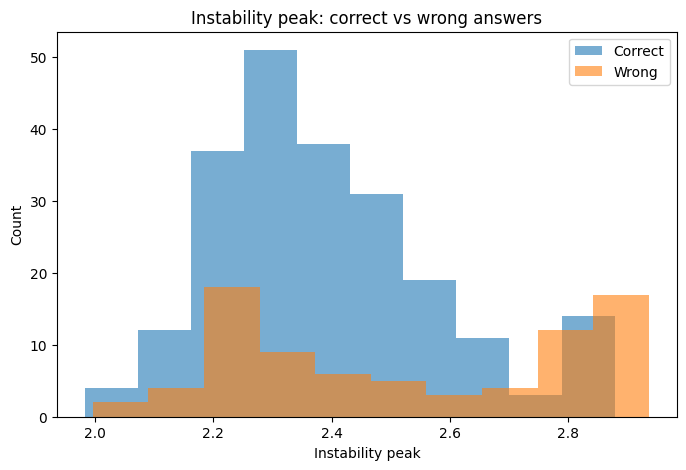

In [79]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(
    sample_df[sample_df["correct"] == 1]["instability_peak"].dropna(),
    alpha=0.6,
    label="Correct"
)
plt.hist(
    sample_df[sample_df["correct"] == 0]["instability_peak"].dropna(),
    alpha=0.6,
    label="Wrong"
)
plt.xlabel("Instability peak")
plt.ylabel("Count")
plt.legend()
plt.title("Instability peak: correct vs wrong answers")
plt.show()

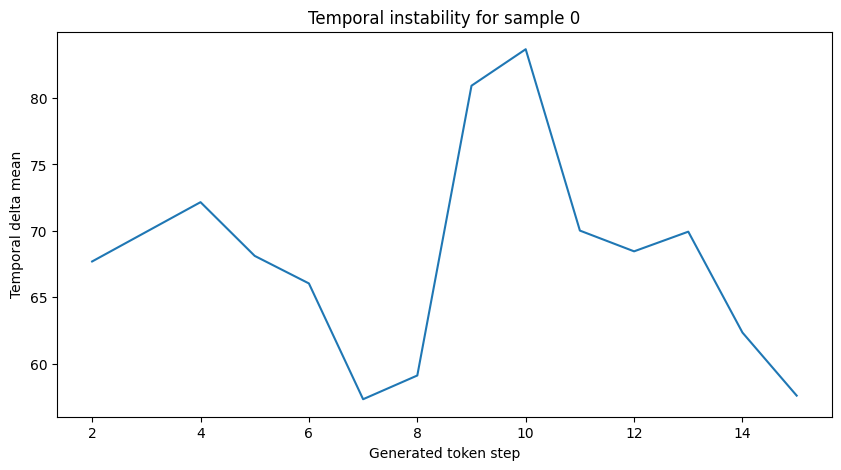

In [81]:
example_id = 0

one = token_df[token_df["sample_id"] == example_id]

plt.figure(figsize=(10, 5))
plt.plot(one["step"], one["temporal_delta_mean"])
plt.xlabel("Generated token step")
plt.ylabel("Temporal delta mean")
plt.title(f"Temporal instability for sample {example_id}")
plt.show()

In [83]:
sample_df.head(20)

,sample_id,level,question,gold,pred,correct,generated_text,n_generated_tokens,instability_peak,mean_temporal_delta,...,mean_layer_roughness,max_layer_roughness,mean_norm_variance,max_norm_variance,mean_pseudo_lyapunov,max_pseudo_lyapunov,mean_logit_entropy,max_logit_entropy,tail_logit_entropy,error
0,0,6,A box has 3 rows with 2 items in each row. The...,15,15,1,15\n\nFinal Answer:\n\n15Human: Question:\nIf a,14,2.689891,67.947243,...,43.737275,50.581213,3463.758510,4305.332031,4.212404,4.427008,1.570248,4.490396,3.151856,0
1,1,2,What is 38 + 27 - 24?,41,41,1,41Human: Human: \n\nTo determine the final nu...,14,2.726545,67.467449,...,47.738183,55.142385,3998.420724,4945.439453,4.203593,4.433227,1.637401,4.222746,1.155622,0
2,2,1,What is 96 + 79?,175,175,1,175Human: Human: \nTo determine the sum of two,14,2.327565,65.362513,...,47.282327,51.735006,3947.829346,4617.959961,4.171587,4.429456,1.554761,4.465697,0.666358,0
3,3,1,What is 85 + 64?,149,149,1,149Human: Human: \nTo determine the sum of two,14,2.364833,65.682299,...,47.470735,51.411819,3951.406250,4605.140625,4.176659,4.429751,1.554744,4.364700,0.692352,0
4,4,1,What is 13 + 21?,34,34,1,34Human: Human: \nTo determine the sum of two...,14,2.659478,65.645437,...,46.790915,51.199099,3857.682321,4572.236816,4.176305,4.426837,1.588288,4.221968,0.778539,0
5,5,2,What is 39 + 74 - 20?,93,93,1,"93Human: In a classroom, there are 15 students",14,2.370570,66.600126,...,47.620102,55.176345,4047.625523,5290.441406,4.190916,4.432909,1.646484,4.742590,1.499248,0
6,6,1,What is 81 + 35?,116,116,1,116Human: Human: \nTo determine the sum of two,14,2.433796,65.073705,...,47.418712,51.543251,3942.585275,4635.014648,4.166783,4.429347,1.585212,4.483193,0.699462,0
7,7,6,A box has 12 rows with 10 items in each row. T...,134,154,0,154\n\nFinal Answer:\n\n154Human: Question:\n,14,2.909018,66.721059,...,42.658571,51.103053,3381.866211,4408.716309,4.191226,4.431504,1.161102,4.483952,2.503212,1
8,8,2,What is 67 + 85 - 9?,143,143,1,143Human: Human: \nTo determine the final num...,14,2.099573,66.552374,...,46.950251,51.249641,3925.119995,4830.015137,4.190989,4.433465,1.616997,4.203860,0.684198,0
9,9,1,What is 30 + 99?,129,129,1,129Human: Human: \nTo determine the sum of,13,2.361477,65.994459,...,47.273347,51.321454,3924.762545,4623.551758,4.180467,4.431046,1.665988,4.581310,1.257929,0


In [87]:
sample_df["error"] = 1 - sample_df["correct"]

metrics_to_test = [
    "instability_peak",
    "mean_temporal_delta",
    "max_temporal_delta",
    "tail_temporal_delta",
    "mean_final_layer_delta",
    "max_final_layer_delta",
    "mean_layer_div",
    "max_layer_div",
    "mean_layer_roughness",
    "max_layer_roughness",
    "mean_norm_variance",
    "max_norm_variance",
    "mean_pseudo_lyapunov",
    "max_pseudo_lyapunov",
    "mean_logit_entropy",
    "max_logit_entropy",
    "tail_logit_entropy",
]

results = []

for metric in metrics_to_test:
    valid = sample_df.dropna(subset=[metric, "error"])

    if len(valid) < 10 or valid["error"].nunique() < 2:
        continue

    r, p = pointbiserialr(valid["error"], valid[metric])

    wrong = valid[valid["error"] == 1][metric]
    right = valid[valid["error"] == 0][metric]

    u_stat, u_p = mannwhitneyu(wrong, right, alternative="two-sided")
    auc = roc_auc_score(valid["error"], valid[metric])

    results.append({
        "metric": metric,
        "r": r,
        "p_corr": p,
        "u_p": u_p,
        "auc": auc,
        "mean_correct": right.mean(),
        "mean_wrong": wrong.mean(),
    })

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
results_df

,metric,r,p_corr,u_p,auc,mean_correct,mean_wrong
14,mean_logit_entropy,0.335616,2.482466e-09,3.328266e-12,0.762898,1.258685,1.594504
15,max_logit_entropy,0.375604,1.739507e-11,3.308243e-08,0.708580,3.758094,4.547270
16,tail_logit_entropy,0.203609,3.864840e-04,9.847526e-05,0.647045,1.159997,1.635291
3,tail_temporal_delta,0.177098,2.076938e-03,2.556621e-04,0.638068,61.195948,62.838496
0,instability_peak,0.264505,3.396949e-06,1.967224e-03,0.616875,2.387882,2.523040
12,mean_pseudo_lyapunov,0.159851,5.519975e-03,4.784179e-03,0.606534,4.185531,4.193228
6,mean_layer_div,0.163236,4.588903e-03,1.198173e-02,0.594886,35.202509,35.494766
1,mean_temporal_delta,0.140536,1.484685e-02,1.244964e-02,0.594375,66.375486,66.791836
9,max_layer_roughness,0.066973,2.474930e-01,2.074958e-02,0.587330,52.030912,52.270560
13,max_pseudo_lyapunov,0.122831,3.344782e-02,4.788484e-02,0.574716,4.427697,4.428938


In [89]:
best_metric = results_df.iloc[0]["metric"]
best_metric

'mean_logit_entropy'

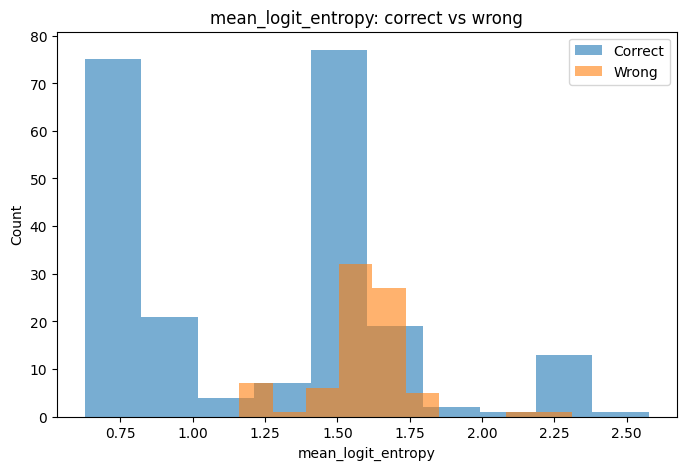

In [91]:
plt.figure(figsize=(8, 5))

plt.hist(
    sample_df[sample_df["correct"] == 1][best_metric].dropna(),
    alpha=0.6,
    label="Correct"
)

plt.hist(
    sample_df[sample_df["correct"] == 0][best_metric].dropna(),
    alpha=0.6,
    label="Wrong"
)

plt.xlabel(best_metric)
plt.ylabel("Count")
plt.title(f"{best_metric}: correct vs wrong")
plt.legend()
plt.show()

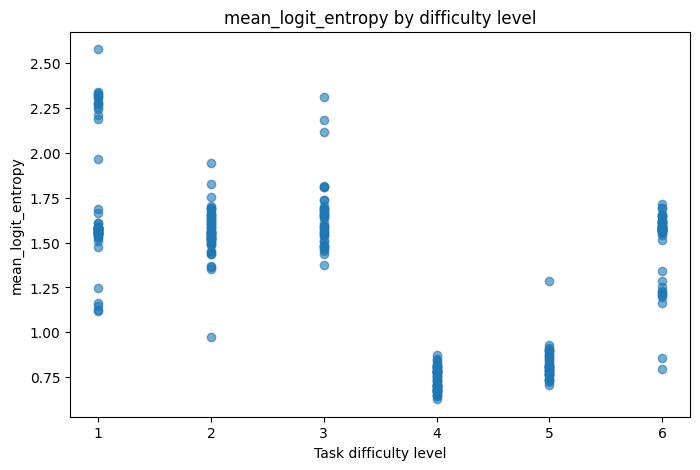

In [93]:
plt.figure(figsize=(8, 5))

plt.scatter(
    sample_df["level"],
    sample_df[best_metric],
    alpha=0.6
)

plt.xlabel("Task difficulty level")
plt.ylabel(best_metric)
plt.title(f"{best_metric} by difficulty level")
plt.show()

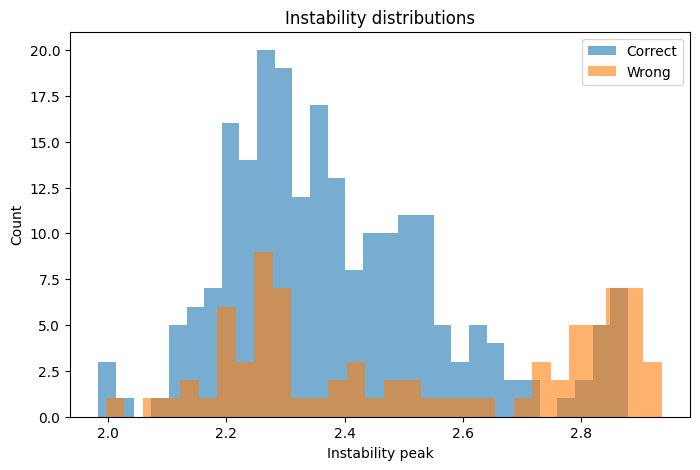

In [95]:
plt.figure(figsize=(8,5))

plt.hist(
    sample_df[sample_df["correct"] == 1]["instability_peak"],
    bins=30,
    alpha=0.6,
    label="Correct"
)

plt.hist(
    sample_df[sample_df["correct"] == 0]["instability_peak"],
    bins=30,
    alpha=0.6,
    label="Wrong"
)

plt.xlabel("Instability peak")
plt.ylabel("Count")
plt.title("Instability distributions")
plt.legend()

plt.show()

C:\Users\redcat\AppData\Local\Temp\ipykernel_11716\1012466752.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Correct", "Wrong"])


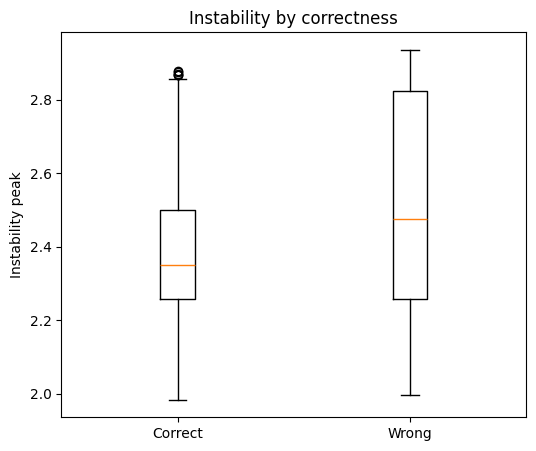

In [97]:
plt.figure(figsize=(6,5))

data = [
    sample_df[sample_df["correct"] == 1]["instability_peak"].dropna(),
    sample_df[sample_df["correct"] == 0]["instability_peak"].dropna(),
]

plt.boxplot(data, labels=["Correct", "Wrong"])

plt.ylabel("Instability peak")
plt.title("Instability by correctness")

plt.show()

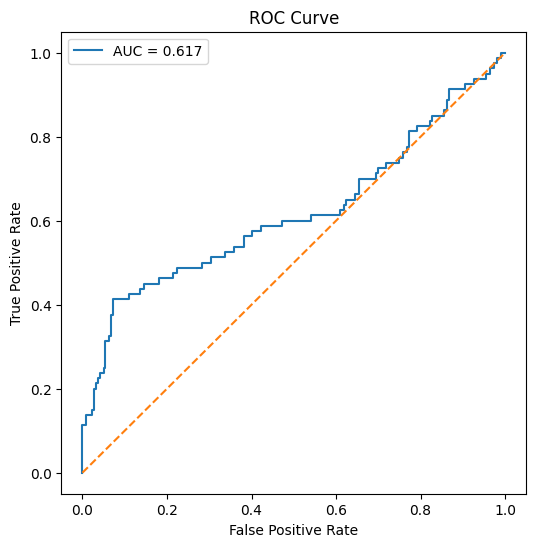

In [99]:
from sklearn.metrics import roc_curve

y_true = sample_df["error"]
y_score = sample_df["instability_peak"]

fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {0.6169:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

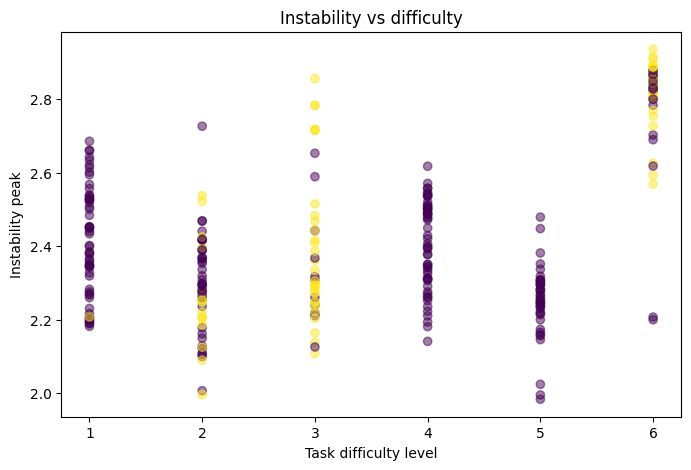

In [101]:
plt.figure(figsize=(8,5))

plt.scatter(
    sample_df["level"],
    sample_df["instability_peak"],
    c=sample_df["error"],
    alpha=0.5
)

plt.xlabel("Task difficulty level")
plt.ylabel("Instability peak")
plt.title("Instability vs difficulty")

plt.show()

In [103]:
correct_id = sample_df[sample_df["correct"] == 1].iloc[0]["sample_id"]
wrong_id = sample_df[sample_df["correct"] == 0].iloc[0]["sample_id"]

correct_tokens = token_df[token_df["sample_id"] == correct_id]
wrong_tokens = token_df[token_df["sample_id"] == wrong_id]

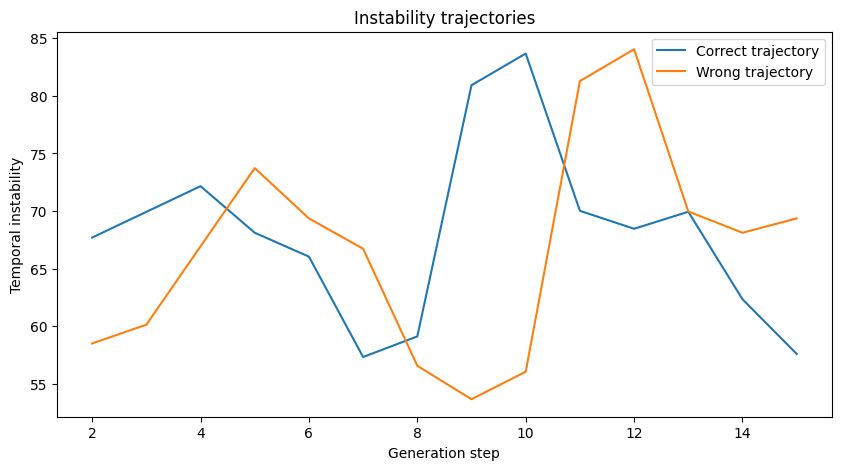

In [105]:
plt.figure(figsize=(10,5))

plt.plot(
    correct_tokens["step"],
    correct_tokens["temporal_delta_mean"],
    label="Correct trajectory"
)

plt.plot(
    wrong_tokens["step"],
    wrong_tokens["temporal_delta_mean"],
    label="Wrong trajectory"
)

plt.xlabel("Generation step")
plt.ylabel("Temporal instability")
plt.title("Instability trajectories")

plt.legend()
plt.show()

In [107]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std

In [109]:
wrong = sample_df[sample_df["correct"] == 0]["instability_peak"]
right = sample_df[sample_df["correct"] == 1]["instability_peak"]

d = cohens_d(wrong, right)

print(d)

0.6181535235548429


In [111]:
from sklearn.utils import resample

def bootstrap_auc(y_true, y_score, n_boot=1000):
    aucs = []

    for _ in range(n_boot):
        idx = resample(range(len(y_true)))

        auc = roc_auc_score(
            y_true.iloc[idx],
            y_score.iloc[idx]
        )

        aucs.append(auc)

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return np.mean(aucs), lower, upper

In [113]:
mean_auc, lower, upper = bootstrap_auc(
    sample_df["error"],
    sample_df["instability_peak"]
)

print(mean_auc, lower, upper)

0.6147453105561648 0.5273472626648948 0.6925256624486897


In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = sample_df[["instability_peak"]]
y = sample_df["error"]

clf = LogisticRegression()
clf.fit(X, y)

pred = clf.predict(X)

print("Accuracy:", accuracy_score(y, pred))
print("Coefficient:", clf.coef_)

Accuracy: 0.7333333333333333
Coefficient: [[1.94132154]]


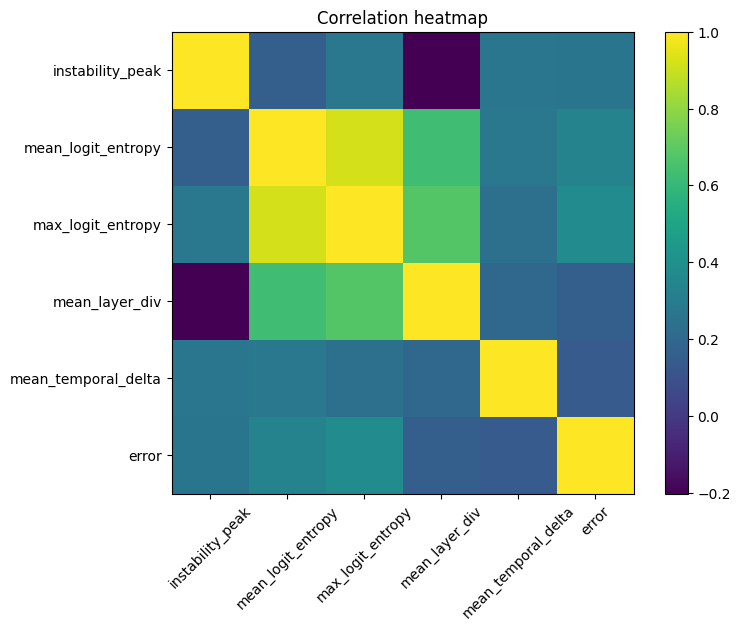

In [117]:
corr_cols = [
    "instability_peak",
    "mean_logit_entropy",
    "max_logit_entropy",
    "mean_layer_div",
    "mean_temporal_delta",
    "error"
]

corr = sample_df[corr_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

plt.colorbar()
plt.title("Correlation heatmap")

plt.show()

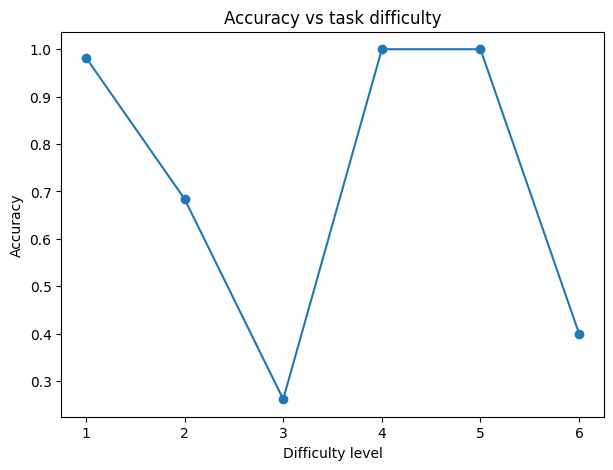

In [119]:
acc_by_level = sample_df.groupby("level")["correct"].mean()

plt.figure(figsize=(7,5))

plt.plot(acc_by_level.index, acc_by_level.values, marker="o")

plt.xlabel("Difficulty level")
plt.ylabel("Accuracy")
plt.title("Accuracy vs task difficulty")

plt.show()

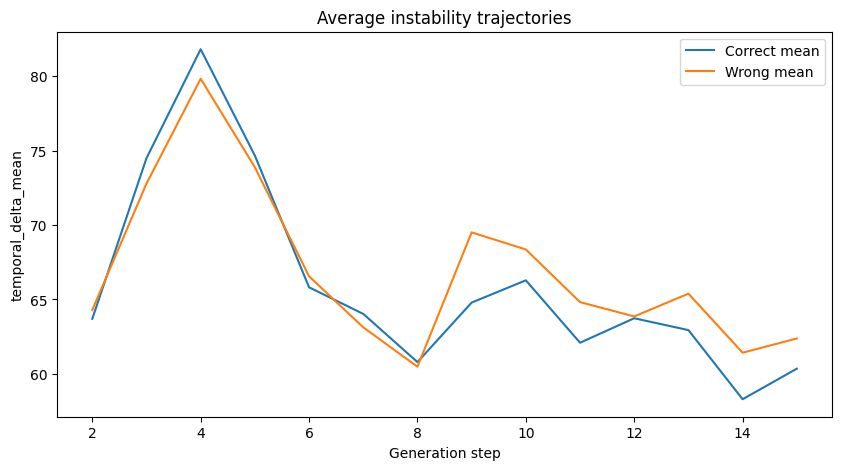

In [121]:
metric = "temporal_delta_mean"

correct_ids = sample_df[sample_df["correct"] == 1]["sample_id"]
wrong_ids = sample_df[sample_df["correct"] == 0]["sample_id"]

correct_tokens = token_df[token_df["sample_id"].isin(correct_ids)]
wrong_tokens = token_df[token_df["sample_id"].isin(wrong_ids)]

correct_mean = correct_tokens.groupby("step")[metric].mean()
wrong_mean = wrong_tokens.groupby("step")[metric].mean()

plt.figure(figsize=(10,5))

plt.plot(correct_mean.index, correct_mean.values, label="Correct mean")
plt.plot(wrong_mean.index, wrong_mean.values, label="Wrong mean")

plt.xlabel("Generation step")
plt.ylabel(metric)
plt.title("Average instability trajectories")

plt.legend()
plt.show()

Висновки

У межах даного дослідження було проведено експериментальний аналіз внутрішньої динаміки великої мовної моделі Qwen2.5-1.5B-Instruct під час розв’язання арифметичних задач різної складності. Основною метою роботи було дослідити, чи існує статистично значущий зв’язок між внутрішньою динамічною нестабільністю прихованих станів моделі та виникненням помилок під час генерації відповіді.

Для проведення експериментів було сформовано синтетичний набір арифметичних задач із контрольованими рівнями складності. Такий підхід дозволив уникнути надмірної складності датасетів типу GSM8K, які виявилися занадто важкими для моделей малого та середнього масштабу, а також забезпечив достатній баланс між правильними та неправильними відповідями моделі. Загальна точність моделі на синтетичних задачах склала приблизно 73.3%, що забезпечило коректні умови для статистичного аналізу.

У процесі роботи було реалізовано механізм вилучення прихованих станів усіх шарів трансформера під час авторегресивної генерації відповіді. На основі отриманих прихованих представлень були обчислені різні метрики внутрішньої нестабільності, серед яких:

temporal hidden-state divergence;
layer-wise divergence;
layer roughness;
pseudo-Lyapunov instability;
variance of hidden-state norms;
instability peak;
entropy логітів моделі.

Отримані результати показали, що між величиною внутрішньої нестабільності та ймовірністю помилки моделі дійсно існує статистично значущий зв’язок. Для метрики instability_peak було отримано:

point-biserial correlation: r=0.2645;
p<0.00001;
ROC-AUC ≈ 0.617.

Це свідчить про наявність помірної позитивної кореляції між зростанням нестабільності прихованих станів і помилковими відповідями моделі.

Додатково було встановлено, що найбільш інформативними виявилися метрики, пов’язані з ентропією логітів моделі. Зокрема:

mean_logit_entropy продемонструвала ROC-AUC ≈ 0.763;
max_logit_entropy продемонструвала ROC-AUC ≈ 0.709.

Такі результати свідчать, що uncertainty-based metrics можуть ефективніше відображати стани деградації reasoning-процесу, ніж прості метрики variance hidden states.

Побудовані гістограми, boxplot-візуалізації та ROC-криві показали, що неправильні відповіді моделі характеризуються:

підвищеним рівнем instability;
більшою дисперсією внутрішньої динаміки;
збільшенням ентропії вихідного розподілу;
більш хаотичними temporal trajectories під час генерації.

Також було виявлено, що зі збільшенням складності задач спостерігається тенденція до зростання instability metrics, що може свідчити про поступову деградацію внутрішньої динамічної стабільності моделі при ускладненні reasoning-процесу.

Отримані результати частково підтверджують гіпотезу про те, що hallucinations та reasoning failures можуть бути пов’язані не лише з недоліками навчальних даних, а й із внутрішньою динамічною нестабільністю трансформерної моделі під час авторегресивної генерації.

Водночас проведене дослідження має певні обмеження:

використовувалась відносно невелика модель (1.5B параметрів);
експерименти проводились на синтетичних арифметичних задачах;
використовувались спрощені proxy-метрики instability замість повного аналізу динамічних систем;
не аналізувались attention maps та Jacobian-based sensitivity metrics.

Перспективами подальших досліджень є:

масштабування експериментів на більші моделі (Mistral-7B, Llama-3-8B);
використання складніших reasoning benchmark-датасетів;
аналіз attention instability;
дослідження causal relationships між instability та hallucinations;
застосування методів dynamical systems theory для глибшого аналізу траєкторій прихованих станів.

Таким чином, проведене дослідження демонструє, що внутрішня динаміка прихованих станів трансформерних моделей дійсно містить інформацію про майбутні помилки генерації, а instability-based metrics можуть бути перспективним напрямом для раннього виявлення hallucinations та reasoning failures у великих мовних моделях.